In [1]:
import gzip
import json

def parse(path):
    g = gzip.open(path, 'r')
    for l in g:
        yield eval(l)

# Load Q&A data
qa_records = []
for record in parse('qa_Electronics.json.gz'):
    qa_records.append(record)

#Load product data with parent_asin as index
product_catalog = {
    item["asin"]: item 
    for item in parse('2018_meta_Electronics.json.gz')
    if "asin" in item
}

print(f"\nQ&A records loaded: {len(qa_records):,}")
print(f"Products loaded: {len(product_catalog):,}")

# Extract unique ASINs from the Q&A data
qa_asins = {r.get("asin") for r in qa_records if r.get("asin")}

# Find the intersection between Q&A ASINs and the Product Catalog keys
overlap_asins = qa_asins & product_catalog.keys()

print(f"Q&A unique ASINs: {len(qa_asins):,}")
print(f"Matched to catalog: {len(overlap_asins):,} ({100*len(overlap_asins)/len(qa_asins):.1f}%)")


Q&A records loaded: 314,263
Products loaded: 756,077
Q&A unique ASINs: 39,371
Matched to catalog: 23,931 (60.8%)


In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

CATEGORY = "Computers" 
# Join Q&A to products
matched = []
for record in qa_records:
    asin = record.get("asin")
    product = product_catalog.get(asin)    
    if product is None:
        continue
    if CATEGORY.lower() not in (product["main_cat"] or "").lower():
        continue
    matched.append({**record, **product}) 

print(f"Matched Q&A rows in '{CATEGORY}': {len(matched):,}")
print(f"Unique products: {len({r['asin'] for r in matched}):,}")

# Have df available for cleaning
qa_cat = pd.DataFrame(matched)

# We combine questions and product features to give LDA more help about the attributes being asked about.
def features_to_text(features) -> str:
    if isinstance(features, list):
        return " ".join(features)
    return str(features) if features else ""

qa_cat["features_text"] = qa_cat["feature"].apply(features_to_text)
STOP = set(stopwords.words("english"))

# Remove specific Q&A specific filler words
QA_NOISE = {
    "work", "anyone", "know", "like", "want", "need", "please",
    "get", "use", "come", "buy", "one", "would", "say", "says",
    "good", "also", "make", "way", "look", "thing", "yes", "really",
    "product", "item", "amazon", "model", "version", "new", "old",
}
STOP = STOP | QA_NOISE
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP and len(t) > 2]
    return " ".join(tokens)

# Mix questions and features to clean
qa_cat["clean_question"] = (qa_cat["question"].fillna("") + " " + qa_cat["features_text"].fillna("")).apply(clean_text)
qa_cat = qa_cat[qa_cat["clean_question"].str.len() > 5].reset_index(drop=True)
print(f"Clean rows ready for topic modeling: {len(qa_cat):,}")
qa_cat[["asin", "title", "question", "clean_question"]].head(3)

Matched Q&A rows in 'Computers': 61,773
Unique products: 7,692
Clean rows ready for topic modeling: 61,532


,asin,title,question,clean_question
0,1394860919,Mini Display Port to VGA Cable Adapter for Mon...,"Hi, does it work with MacBook Air 13.3"" latest...",macbook air latest thanks brand displayport co...
1,1394860919,Mini Display Port to VGA Cable Adapter for Mon...,does this cable enable a macbook air 11 inch l...,cable enable macbook air inch late connect bra...
2,1394860919,Mini Display Port to VGA Cable Adapter for Mon...,Does it work with MacBook Air mid2012?,macbook air mid brand displayport compliant re...


/Users/mauriciosoria/Desktop/Tue/BEP/final version/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1400.22it/s]
2026-06-28 20:10:22,448 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1923/1923 [03:57<00:00,  8.09it/s]
2026-06-28 20:14:20,487 - BERTopic - Embedding - Completed ✓
2026-06-28 20:14:20,488 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-28 20:17:44,933 - BERTopic - Dimensionality - Completed ✓
2026-06-28 20:17:44,948 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-28 20:18:32,650 - BERTopic - Cluster - Completed ✓
2026-06-28 20:18:32,654 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-28 

Topics discovered: 99

Topic  0: memory, fan, port, support, ddr, slot, ram, flash, ghz, core, cpu, ram memory
Topic  1: rpm_hard drive, rpm_hard, inch screen, drive inch, intel, intel core, drive, ghz, window, core, core ghz, graphic window
Topic  2: ipad, keyboard, key, case, mouse, stand, design, cover, tablet, ipad mini, bluetooth, mini
Topic  3: monitor, vga, resolution, display, hdmi, input, color, dvi, port, cable, full, ratio
Topic  4: router, wireless, mbps, network, ethernet, antenna, modem, wifi, internet, speed, connection, range
Topic  5: speaker, audio, sound, bluetooth, headset, music, microphone, stereo, device, headphone, control, plug
Topic  6: usb, sata, hub, transfer_rate, device, hard_drive, ide, mac, gbps, transfer, support, plug_play
Topic  7: card, memory card, transfer, speed, sandisk, uhs, sdhc, photo, memory, micro, read, file
Topic  8: dvd, dvd dvd, rom, dvd_rom, disc, dvd ram, blu_ray, buffer, read, write_speed, write, drive
Topic  9: pocket, macbook_pro, f

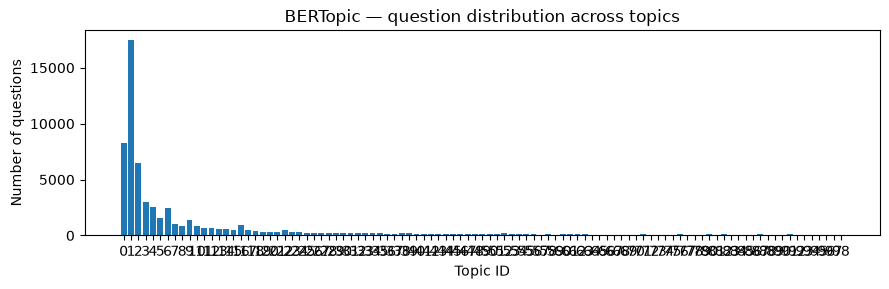

In [ ]:
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from gensim.models.phrases import Phrases, Phraser
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Bigrams 
tokenized = [word_tokenize(q) for q in qa_cat["clean_question"]]
bigram_model  = Phrases(tokenized, min_count=10, threshold=8)
bigram_phraser = Phraser(bigram_model)
qa_cat["clean_bigrammed"] = [" ".join(bigram_phraser[tokens]) for tokens in tokenized]
docs = qa_cat["clean_bigrammed"].tolist()

# submodels
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Vocab contraints
vectorizer_model = CountVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=4000,
    ngram_range=(1, 2),
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics="auto",
    top_n_words=12,
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(docs)

# Handle noise
outlier_mask = np.array(topics) == -1
if outlier_mask.any() and probs is not None:
    # outlier rows get the argmax of their row
    topics = np.array(topics)
    topics[outlier_mask] = probs[outlier_mask].argmax(axis=1)
    topics = topics.tolist()
qa_cat["topic_id"] = topics

# print words
unique_topics = sorted(set(qa_cat["topic_id"]))
print(f"Topics discovered: {len(unique_topics)}\n")
for t_id in unique_topics:
    words = [w for w, _ in topic_model.get_topic(t_id)[:12]]
    print(f"Topic {t_id:2d}: {', '.join(words)}")

# c_v
gensim_texts = [d.split() for d in docs]
gensim_dict  = Dictionary(gensim_texts)
gensim_corpus = [gensim_dict.doc2bow(t) for t in gensim_texts]

top_words_per_topic = [[w for w, _ in topic_model.get_topic(t)[:10]]for t in unique_topics]
cm = CoherenceModel(
    topics=top_words_per_topic,
    texts=gensim_texts,
    corpus=gensim_corpus,
    dictionary=gensim_dict,
    coherence="c_v",
)
print(f"\nBERTopic coherence (c_v): {cm.get_coherence():.4f}")

# visualization
topic_counts = qa_cat["topic_id"].value_counts().sort_index()
plt.figure(figsize=(9, 3))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.xlabel("Topic ID"); plt.ylabel("Number of questions")
plt.title("BERTopic — question distribution across topics")
plt.tight_layout()
#plt.savefig("bertopic_distribution.png", dpi=130); plt.show()


In [4]:
topic_labels = {
0: "memory port",
1: "rpm hard drive",
2: "keyboard / tablet",
3: "monitor",
4: "router",
5: "audio",
6: "usb",
7: "memory card",
8: "dvd",
9: "laptop",
}

qa_cat["topic_label"] = qa_cat["topic_id"].map(topic_labels)

demand_weights = (topic_counts / topic_counts.sum()).rename("weight")
demand_weights.index = demand_weights.index.map(topic_labels)
print("\nConsumer demand weights")
print(demand_weights.round(3).to_string())

topic_cols = list(topic_labels.values())


Consumer demand weights
topic_id
memory port          0.134
rpm hard drive       0.284
keyboard / tablet    0.106
monitor              0.048
router               0.042
audio                0.025
usb                  0.040
memory card          0.016
dvd                  0.014
laptop               0.023
NaN                  0.014
NaN                  0.010
NaN                  0.010
NaN                  0.009
NaN                  0.009
NaN                  0.008
NaN                  0.016
NaN                  0.009
NaN                  0.006
NaN                  0.005
NaN                  0.005
NaN                  0.005
NaN                  0.008
NaN                  0.005
NaN                  0.004
NaN                  0.004
NaN                  0.004
NaN                  0.004
NaN                  0.004
NaN                  0.004
NaN                  0.003
NaN                  0.004
NaN                  0.004
NaN                  0.003
NaN                  0.003
NaN                  

In [5]:
N_PRODUCTS = 10

# Topic distribution per product
topic_dist = (qa_cat.groupby("asin")["topic_id"].value_counts(normalize=True).unstack(fill_value=0))
topic_dist.columns = [topic_labels.get(c, f"topic_{c}") for c in topic_dist.columns]

# Improve the metadata by getting the catalog dict
def get_product_meta(asin: str) -> dict:
    p = product_catalog.get(asin, {})
    return {
        "title": p.get("title", ""),
        "main_cat": p.get("main_cat", ""),
        "average_rating": p.get("average_rating"),
        "rating_number": p.get("rating_number"),
        "price": p.get("price"),
        "store": p.get("store", ""),
        "features_text": " | ".join(p.get("feature", [])),
        "description_text": " ".join(
            [s for s in p.get("description", []) if isinstance(s, str)]
        ),
    }

meta_rows = {asin: get_product_meta(asin) for asin in topic_dist.index}
meta_df = pd.DataFrame(meta_rows).T
meta_df.index.name = "asin"

topic_dist = topic_dist.join(meta_df)
topic_dist["n_questions"] = qa_cat.groupby("asin").size()

# Gets a filter of min 5 questions per product
MIN_QUESTIONS = 5
topic_dist = topic_dist[topic_dist["n_questions"] >= MIN_QUESTIONS].copy()
print(f"Products with ≥{MIN_QUESTIONS} questions: {len(topic_dist):,}")

# Greedy coverage selection
selected = []
covered = np.zeros(len(topic_cols))
remaining = topic_dist.copy()

for _ in range(N_PRODUCTS):
    if remaining.empty:
        break
    least_covered_idx = covered.argmin()
    least_covered_topic = topic_cols[least_covered_idx]
    if least_covered_topic not in remaining.columns:
        break
    best_asin = remaining[least_covered_topic].idxmax()
    selected.append(best_asin)
    covered += remaining.loc[best_asin, topic_cols].values.astype(float)
    remaining = remaining.drop(index=best_asin)

# Builds and displays selection table
# Change this line:
display_cols = ["title", "main_cat", "n_questions", "description_text", "average_rating", "rating_number", "price", "features_text"]
selection_table  = topic_dist.loc[selected, display_cols + topic_cols].copy()
selection_table.index.name = "asin"

print("\nSelected products")
print(selection_table[display_cols].to_string())
print("\nTopic coverage per selected product")
print(selection_table[topic_cols].round(3).to_string())

# Select products to use
selected_products = {
    asin: {
        **get_product_meta(asin),
        "n_questions"  : int(topic_dist.loc[asin, "n_questions"]),
        "topic_profile": topic_dist.loc[asin, topic_cols].astype(float).round(4).to_dict(),
    }
    for asin in selected
}

# Export selections
selection_table.to_csv("selected_products.csv")

print("Products chosen:")
for asin, meta in selected_products.items():
    print(f"\n {asin} | {meta['title'][:60]}")
    print(f"category: {meta['main_cat']} | " f"questions: {meta['n_questions']} | " f"rating: {meta['average_rating']}")

Products with ≥5 questions: 6,472

Selected products
                                                                                                                                                                                                               title   main_cat  n_questions                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [ ]:
# Get BERTopic vocabulary
TOP_N_WORDS = 12
cluster_vocab = {}
for topic_id in sorted(topic_labels.keys()):
    words_scores = topic_model.get_topic(topic_id)
    if words_scores:
        cluster_vocab[topic_id] = words_scores[:TOP_N_WORDS]

print("Cluster vocabularies from BERTopic:")
for tid, ws in cluster_vocab.items():
    words = [w for w, _ in ws]
    print(f"  Topic {tid} ({topic_labels[tid]:20s}): {words}")
# Assign primary cluster
product_cluster = (
    qa_cat[qa_cat["asin"].isin(selected)]
    .groupby("asin")["topic_id"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

print("\nProduct -> primary cluster:")
for asin in selected:
    cid = product_cluster.get(asin, -1)
    title = product_catalog.get(asin, {}).get("title", asin)[:55]
    print(f"  [{cid}] {topic_labels.get(cid,'?'):20s}  |  {title}")

# question only cleaned columns
def clean_text_question_only(text: str) -> str:
    text= str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens if t not in STOP and len(t) > 2]
    return " ".join(tokens)

qa_cat["clean_question_only"] = (qa_cat["question"].fillna("").apply(clean_text_question_only))
tokenized_q_only = [word_tokenize(q) for q in qa_cat["clean_question_only"]]
qa_cat["clean_bigrammed_question_only"] = [" ".join(bigram_phraser[tokens]) for tokens in tokenized_q_only]

# All 108 unique terms across all 9 clusters
all_cluster_words = []
word_to_cluster = {} 

for cid, ws in cluster_vocab.items():
    for word, _ in ws:
        if word not in word_to_cluster:
            all_cluster_words.append(word)
            word_to_cluster[word] = (cid, topic_labels[cid])

print(f"\nTotal vocabulary terms across all clusters: {len(all_cluster_words)}")

# cross-cluster demand function
def get_cross_cluster_demand(asin: str) -> pd.Series:
    q_bigrammed = qa_cat[qa_cat["asin"] == asin][
        "clean_bigrammed_question_only"].tolist()
    q_raw       = qa_cat[qa_cat["asin"] == asin][
        "clean_question_only"].tolist()
    if not q_bigrammed:
        return pd.Series({w: 0 for w in all_cluster_words})
    scores = {}
    for word in all_cluster_words:
        word_clean = word.replace("_", " ").lower()
        parts = [p for p in word_clean.split() if len(p) > 2]

        found = any(word_clean in q.lower() for q in q_bigrammed)
        if not found:
            found = any(word_clean in q.lower() for q in q_raw)
        if not found and len(parts) > 1:
            found = any(
                all(part in q.lower() for part in parts)
                for q in q_raw
            )
        scores[word] = int(found)
    return pd.Series(scores)

# cross-cluster demand matrix
cross_demand_df = pd.DataFrame({asin: get_cross_cluster_demand(asin) for asin in selected}).T
cross_demand_df.index.name = "asin"

#  demanded terms per product
product_demanded_subtopics = {
    asin: cross_demand_df.loc[asin][cross_demand_df.loc[asin] == 1].index.tolist()
    for asin in selected
}
print("\nCROSS-CLUSTER DEMAND PROFILES PER PRODUCT")
print("(binary: term appears in any question across ALL cluster vocabularies)")
for asin in selected:
    title = product_catalog.get(asin, {}).get("title", asin)[:58]
    primary_cid = product_cluster.get(asin, -1)
    primary_lbl = topic_labels.get(primary_cid, "unknown")
    demanded = product_demanded_subtopics[asin]
    n_qs = len(qa_cat[qa_cat["asin"] == asin])

    # Group demanded terms by their cluster origin
    by_cluster = {}
    for term in demanded:
        _, clbl = word_to_cluster[term]
        by_cluster.setdefault(clbl, []).append(term)

    print(f"\n  {title}")
    print(f" Primary cluster: [{primary_lbl}] | "
          f"{n_qs} questions | {len(demanded)} demanded terms")
    if demanded:
        for clbl, terms in sorted(by_cluster.items()):
            marker = " <- primary cluster" if clbl == primary_lbl else ""
            print(f"[{clbl}]{marker}: {', '.join(terms)}")
    else:
        print(f" (no terms matched - product's questions use domain-specific "
              f"vocabulary not in BERTopic cluster vocab)")

Cluster vocabularies from BERTopic:
  Topic 0 (memory port         ): ['memory', 'fan', 'port', 'support', 'ddr', 'slot', 'ram', 'flash', 'ghz', 'core', 'cpu', 'ram memory']
  Topic 1 (rpm hard drive      ): ['rpm_hard drive', 'rpm_hard', 'inch screen', 'drive inch', 'intel', 'intel core', 'drive', 'ghz', 'window', 'core', 'core ghz', 'graphic window']
  Topic 2 (keyboard / tablet   ): ['ipad', 'keyboard', 'key', 'case', 'mouse', 'stand', 'design', 'cover', 'tablet', 'ipad mini', 'bluetooth', 'mini']
  Topic 3 (monitor             ): ['monitor', 'vga', 'resolution', 'display', 'hdmi', 'input', 'color', 'dvi', 'port', 'cable', 'full', 'ratio']
  Topic 4 (router              ): ['router', 'wireless', 'mbps', 'network', 'ethernet', 'antenna', 'modem', 'wifi', 'internet', 'speed', 'connection', 'range']
  Topic 5 (audio               ): ['speaker', 'audio', 'sound', 'bluetooth', 'headset', 'music', 'microphone', 'stereo', 'device', 'headphone', 'control', 'plug']
  Topic 6 (usb            

In [7]:
# coverage
# load descriptions
desc_df = pd.read_csv("selected_products_2.csv")
desc_df = desc_df[desc_df["condition"].notna() & (desc_df["condition"].str.strip() != "")].copy()
desc_df["description_text"] = (desc_df["description_text"].fillna("").str.lower())

AI_CONDITIONS = ["default", "quality_persona", "neutral_tone", "neutral_tone_quality_persona"]
HUMAN_CONDITION = "human"

print(f"Descriptions loaded: {len(desc_df)}")
print(f"Conditions: {sorted(desc_df['condition'].unique())}")

embedding_model_cov = SentenceTransformer("all-MiniLM-L6-v2")

print(f"\nPre-computing embeddings for {len(all_cluster_words)} terms...")
term_embeddings = {
    w: embedding_model_cov.encode([w.replace("_", " ")])[0]
    for w in all_cluster_words
}
SEMANTIC_THRESHOLD = 0.45
# Hybrid coverage function
def coverage_vector(text: str, terms: list) -> dict:
    if not text or not terms:
        return {t: 0 for t in terms}

    text_lower = text.lower()
    sentences = nltk.sent_tokenize(text)
    sent_embs = embedding_model_cov.encode(sentences) if sentences else []

    result = {}
    for word in terms:
        word_clean = word.replace("_", " ").lower()
        if word_clean in text_lower:
            result[word] = 1
            continue
        if not sentences:
            result[word] = 0
            continue
        w_emb = term_embeddings.get(word)
        if w_emb is None:
            result[word] = 0
            continue
        sims = cosine_similarity([w_emb], sent_embs)[0]
        result[word] = 1 if sims.max() >= SEMANTIC_THRESHOLD else 0
    return result
# cov to all descriptions
coverage_rows = []

for _, row in desc_df[desc_df["asin"].isin(selected)].iterrows():
    asin = row["asin"]
    condition = row["condition"]
    variant = row.get("variant", 0)
    text = str(row["description_text"])
    demanded = product_demanded_subtopics.get(asin, [])
    if not demanded:
        continue
    cov = coverage_vector(text, demanded)
    coverage_rows.append({
        "asin": asin,
        "condition": condition,
        "variant": variant,
        "primary_cluster": topic_labels.get(product_cluster.get(asin, -1), "unknown"),
        **cov,
    })
desc_cov = pd.DataFrame(coverage_rows).fillna(0)
ai_mask = desc_cov["condition"].isin(AI_CONDITIONS)
human_mask = desc_cov["condition"] == HUMAN_CONDITION


print(f"Shape: {desc_cov.shape}")
print(f"AI rows: {ai_mask.sum()}")
print(f"Human rows: {human_mask.sum()}")
print(f"Term columns: {len([c for c in desc_cov.columns if c not in ['asin','condition','variant','primary_cluster']])}")

Descriptions loaded: 130
Conditions: ['default', 'human', 'neutral_tone', 'neutral_tone_quality_persona', 'quality_persona']


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6703.91it/s]



Pre-computing embeddings for 108 terms...
Shape: (130, 46)
AI rows: 120
Human rows: 10
Term columns: 42


In [ ]:
#cross-cluster demanded terms

CONDITION_META = {
    "default": {"has_persona": 0, "has_neutral_tone": 0},
    "quality_persona": {"has_persona": 1, "has_neutral_tone": 0},
    "neutral_tone": {"has_persona": 0, "has_neutral_tone": 1},
    "neutral_tone_quality_persona": {"has_persona": 1, "has_neutral_tone": 1},
    "human": {"has_persona": 0, "has_neutral_tone": 0},
}

rows = []
meta_cols = {"asin", "condition", "variant", "primary_cluster"}

for _, desc_row in desc_cov.iterrows():
    asin = desc_row["asin"]
    condition = desc_row["condition"]
    variant = desc_row["variant"]
    primary_cluster = desc_row["primary_cluster"]
    primary_cid = product_cluster.get(asin, -1)
    cond_meta = CONDITION_META.get(condition, {"has_persona": 0, "has_neutral_tone": 0})

    demanded = product_demanded_subtopics.get(asin, [])

    for term in demanded:
        if term not in desc_row.index:
            continue
        term_cid, term_cluster = word_to_cluster.get(term, (-1, "unknown"))
        rows.append({
            "asin": asin,
            "condition": condition,
            "variant": variant,
            "primary_cluster": primary_cluster,
            "term": term,
            "term_cluster": term_cluster,
            "is_primary_cluster": int(term_cid == primary_cid),
            "covered": int(desc_row[term]),
            "has_persona": cond_meta["has_persona"],
            "has_neutral_tone": cond_meta["has_neutral_tone"],
            "is_human": int(condition == "human"),
            "product_short": (product_catalog.get(asin, {}).get("title", asin)[:35]),
        })

analysis_df = pd.DataFrame(rows)
ai_df = analysis_df[analysis_df["is_human"] == 0].copy()
human_df = analysis_df[analysis_df["is_human"] == 1].copy()

print("analysis_df - cross-cluster demanded terms")
print(f"Total rows: {len(analysis_df):,}")
print(f"AI rows: {len(ai_df):,}")
print(f"Human rows: {len(human_df):,}")
print(f"Unique products: {analysis_df['asin'].nunique()}")
print(f"Unique terms: {analysis_df['term'].nunique()}")
print(f"Primary cluster rows: {(ai_df['is_primary_cluster']==1).sum()}")
print(f"Cross-cluster rows: {(ai_df['is_primary_cluster']==0).sum()}")
print(f"Overall AI coverage: {ai_df['covered'].mean():.3f}")
print(f"Overall AI miss rate: {1-ai_df['covered'].mean():.3f}")


# product-level coverage summary
print("\nPRODUCT-LEVEL CROSS-CLUSTER DEMAND vs AI COVERAGE")
print("Gap = AI coverage − 1.0 (miss rate = 1 − AI coverage)")
print("P = term from primary cluster | X = term from different cluster")

product_summary_rows = []
for asin in selected:
    title = product_catalog.get(asin, {}).get("title", asin)[:55]
    primary_cid = product_cluster.get(asin, -1)
    primary_lbl = topic_labels.get(primary_cid, "unknown")
    demanded = product_demanded_subtopics.get(asin, [])

    if not demanded:
        print(f"\n{title}  — no demanded terms")
        continue

    print(f"\n{title}")
    print(f"Primary cluster: [{primary_lbl}]")
    print(f"{'':2s}{'Term':<22s}  {'Origin cluster':<22s}  "
          f"{'AI cov':>8s}  {'Human':>8s}  {'Miss':>8s}  {'Status'}")
    print(f"  {'-'*2}{'─'*22}  {'─'*22}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")

    for term in sorted(demanded, key=lambda t: (
            word_to_cluster[t][0] != primary_cid, word_to_cluster[t][1])):
        term_cid, term_lbl = word_to_cluster.get(term, (-1, "unknown"))
        marker = "P" if term_cid == primary_cid else "X"

        ai_cov = ai_df[(ai_df["asin"] == asin) & (ai_df["term"] == term)]["covered"].mean()
        hum_cov = human_df[(human_df["asin"] == asin) & (human_df["term"] == term)]["covered"].mean()

        miss   = 1.0 - ai_cov if not np.isnan(ai_cov) else np.nan
        status = ("✅ covered" if miss < 0.20 else
                  "~ partial" if miss < 0.60 else
                  "❌ missed")

        print(f"[{marker}] {term:<22s}  {term_lbl:<22s}  "
              f"{ai_cov:>7.1%}  {hum_cov:>7.1%}  {miss:>7.1%}  {status}")

        product_summary_rows.append({
            "asin": asin,
            "title": title,
            "primary_cluster": primary_lbl,
            "term": term,
            "term_cluster": term_lbl,
            "is_primary_cluster": int(term_cid == primary_cid),
            "ai_coverage": ai_cov,
            "human_coverage":hum_cov,
            "miss_rate": miss,
            "gap": ai_cov - 1.0,
        })

product_summary_df = pd.DataFrame(product_summary_rows)


# cov by condition and term
condition_term_cov = (ai_df.groupby(["term", "condition"])["covered"].mean().unstack(fill_value=np.nan).round(3))
print("\n\nCoverage rate by condition × term:")
print(condition_term_cov.to_string())

# gap table
gap_rows = []
for term in ai_df["term"].unique():
    sub = ai_df[ai_df["term"] == term]
    avg_cov = sub["covered"].mean()
    miss = 1.0 - avg_cov
    term_cid, term_lbl = word_to_cluster.get(term, (-1, "unknown"))
    gap_rows.append({
        "term": term,
        "term_cluster": term_lbl,
        "ai_coverage": avg_cov,
        "miss_rate": miss,
        "gap": avg_cov - 1.0,
        "status"     : ("✅ covered" if miss < 0.20 else
                        "~ partial" if miss < 0.60 else
                        "❌ missed"),
    })

gap_df = (pd.DataFrame(gap_rows).set_index("term").sort_values("miss_rate", ascending=False))

print("\nInformation gap table")
print(gap_df.to_string())

# primary vs cross-cluster coverage summary
print("\n PRIMARY vs CROSS-CLUSTER COVERAGE SUMMARY")

for label, mask in [("Primary cluster terms", ai_df["is_primary_cluster"] == 1),
                    ("Cross-cluster terms",   ai_df["is_primary_cluster"] == 0)]:
    sub = ai_df[mask]
    print(f"\n  {label}")
    print(f"Unique terms: {sub['term'].nunique()}")
    print(f"Total (term×desc) obs: {len(sub):,}")
    print(f"Mean AI coverage: {sub['covered'].mean():.1%}")
    print(f"Mean miss rate: {1-sub['covered'].mean():.1%}")

print("\n  Coverage by cluster (all products combined):")
print(f"  {'Cluster':<25s}  {'Terms':>6s}  {'AI cov':>8s}  {'Miss':>8s}")
print(f"  {'-'*25}  {'-'*6}  {'-'*8}  {'-'*8}")
for clbl, grp in ai_df.groupby("term_cluster"):
    print(f"  {clbl:<25s}  {grp['term'].nunique():>6d}  "
          f"{grp['covered'].mean():>7.1%}  "
          f"{1-grp['covered'].mean():>7.1%}")

# overcov diagnostic
overcov_rows = []
non_meta = [c for c in desc_cov.columns if c not in {"asin", "condition", "variant", "primary_cluster"}]

for _, desc_row in desc_cov[ai_mask].iterrows():
    asin = desc_row["asin"]
    demanded = set(product_demanded_subtopics.get(asin, []))
    for term in non_meta:
        if term not in demanded and desc_row.get(term, 0) == 1:
            t_cid, t_lbl = word_to_cluster.get(term, (-1, "unknown"))
            overcov_rows.append({
                "asin": asin,
                "condition": desc_row["condition"],
                "term": term,
                "term_cluster": t_lbl,
                "product_short": (product_catalog.get(asin, {}).get("title", asin)[:40]),
            })

overcov_df = pd.DataFrame(overcov_rows) if overcov_rows else pd.DataFrame()
print("\ncOver-coverage: AI covers non-demanded terms:")
if not overcov_df.empty:
    print(overcov_df.groupby(["term", "term_cluster"])["asin"].count().sort_values(ascending=False).rename("times").to_string())
else:
    print("None detected.")

analysis_df - cross-cluster demanded terms
Total rows: 923
AI rows: 852
Human rows: 71
Unique products: 10
Unique terms: 42
Primary cluster rows: 240
Cross-cluster rows: 612
Overall AI coverage: 0.424
Overall AI miss rate: 0.576

PRODUCT-LEVEL CROSS-CLUSTER DEMAND vs AI COVERAGE
Gap = AI coverage − 1.0 (miss rate = 1 − AI coverage)
P = term from primary cluster | X = term from different cluster

StarTech.com Computer Power supply ( internal ) - ATX -
Primary cluster: [memory port]
  Term                    Origin cluster            AI cov     Human      Miss  Status
  --──────────────────────  ──────────────────────  ────────  ────────  ────────  ────────
[X] plug                    audio                      0.0%     0.0%   100.0%  ❌ missed

Barnes &amp; Noble NOOK Tablet 16gb (Color, BNTV250)
Primary cluster: [rpm hard drive]
  Term                    Origin cluster            AI cov     Human      Miss  Status
  --──────────────────────  ──────────────────────  ────────  ────────  ─

In [ ]:
# prepare for mixed-effects modeling
import statsmodels.formula.api as smf
from scipy.stats import chi2, kruskal
import warnings
warnings.filterwarnings("ignore")

def fit_mixedlm_robust(formula, data, groups, label=""):
    for method in [["lbfgs"], ["cg"], ["bfgs"], ["nm"]]:
        try:
            r = smf.mixedlm(formula, data=data, groups=groups).fit(reml=False, method=method, disp=False)
            print(f" [{label}] Converged: {method[0]}")
            return r, f"MixedLM/{method[0]}"
        except Exception:
            continue
    print(f"[{label}] Fallback OLS/HC3")
    return smf.ols(formula, data=data).fit(cov_type="HC3"), "OLS/HC3"

def coef_table(result):
    try:
        fe, bse, pval, ci = (result.fe_params, result.bse_fe, result.pvalues, result.conf_int())
    except AttributeError:
        fe, bse, pval, ci = (result.params, result.bse, result.pvalues, result.conf_int())
    return pd.DataFrame({
        "coef": fe, "SE": bse,
        "p": pval, "CI_2.5": ci.iloc[:, 0], "CI_97.5": ci.iloc[:, 1],
    })

def print_icc(result, label):
    try:
        var_re  = float(result.cov_re.iloc[0, 0])
        var_res = float(result.scale)
        icc     = var_re / (var_re + var_res)
        print(f"  [{label}] σ²_product={var_re:.4f}  "
              f"σ²_residual={var_res:.4f}  ICC={icc:.4f}")
        return icc
    except AttributeError:
        print(f"[{label}] OLS fallback")
        return None

model_df = ai_df.copy()
model_df["condition"] = pd.Categorical(
    model_df["condition"],
    categories=["default", "quality_persona", "neutral_tone", "neutral_tone_quality_persona"],
)

print("PRE-MODEL DIAGNOSTICS")
print(f"Rows: {len(model_df):,}")
print(f"Products: {model_df['asin'].nunique()}")
print(f"Unique terms: {model_df['term'].nunique()}")
print(f"Primary cluster rows: {(model_df['is_primary_cluster']==1).sum()}")
print(f"Cross-cluster rows: {(model_df['is_primary_cluster']==0).sum()}")
print(f"Overall coverage: {model_df['covered'].mean():.3f}")
print(f"\nCondition counts:\n{model_df['condition'].value_counts().to_string()}")


# Model 1: Coverage ~ Condition + is_primary_cluster
# Tests whether (a) prompt conditions affect coverage, and
# (b) AI covers primary-cluster terms better than cross-cluster terms.

print("\nMODEL 1 — covered ~ C(condition) + is_primary_cluster")
print("Intercept = baseline coverage, default condition, cross-cluster term")
print("is_primary_cluster coef = extra coverage for primary-cluster terms")

r1, m1 = fit_mixedlm_robust("covered ~ C(condition, Treatment('default')) + is_primary_cluster", data=model_df, groups=model_df["asin"], label="Model 1")
c1 = coef_table(r1)
print("\nFixed-effect coefficients:")
print(c1.round(4).to_string())
icc1 = print_icc(r1, "Model 1")

try:
    re_df = pd.DataFrame(r1.random_effects).T
    re_df.index.name = "asin"
    re_df.columns = ["intercept"]
    re_df["title"] = re_df.index.map(lambda a: product_catalog.get(a, {}).get("title", a)[:40])
    print("\nRandom intercepts per product:")
    print(re_df.sort_values("intercept", ascending=False).to_string())
except Exception:
    re_df = None

# Model 2: Lever decomposition
print("\n MODEL 2 — covered ~ has_persona + has_neutral_tone + is_primary_cluster")

r2, m2 = fit_mixedlm_robust("covered ~ has_persona + has_neutral_tone + is_primary_cluster", data=model_df, groups=model_df["asin"], label="Model 2")
c2 = coef_table(r2)
print("\nFixed-effect coefficients:")
print(c2.round(4).to_string())
icc2 = print_icc(r2, "Model 2")

if "MixedLM" in m1 and "MixedLM" in m2:
    lr_stat = 2 * abs(r1.llf - r2.llf)
    lr_df = abs(len(c1) - len(c2))
    lr_p = 1 - chi2.cdf(lr_stat, max(lr_df, 1))
    print(f"\nLR test: χ²({lr_df}) = {lr_stat:.3f},  p = {lr_p:.4f}")

# check
print("KRUSKAL-WALLIS: coverage across conditions")
cond_groups = [
    model_df[model_df["condition"] == c]["covered"].values
    for c in model_df["condition"].cat.categories
    if c in model_df["condition"].values
]
if len(cond_groups) >= 2:
    h, p = kruskal(*cond_groups)
    print(f" H = {h:.3f},  p = {p:.4f}")
    print(f" -> {'Significant' if p < 0.05 else 'No significant'} " f"difference across conditions")

print("\nMean coverage by condition:")
print(model_df.groupby("condition")["covered"].mean().round(3).to_string())

print("\nMean coverage by primary vs cross-cluster:")
print(model_df.groupby("is_primary_cluster")["covered"].mean().rename({0: "cross-cluster", 1: "primary"}).round(3).to_string())

# LOSO robustness
b_full = (c1.loc["Intercept", "coef"] if "Intercept" in c1.index else np.nan)
print(f"LOSO ROBUSTNESS  (full-sample intercept = {b_full:.4f})")

loso_rows = []
for excl in sorted(model_df["term"].unique()):
    sub = model_df[model_df["term"] != excl].copy()
    r_l, _ = fit_mixedlm_robust(
        "covered ~ C(condition, Treatment('default')) + is_primary_cluster",
        data=sub, groups=sub["asin"], label=f"excl {excl}"
    )
    ct = coef_table(r_l)
    b = ct.loc["Intercept", "coef"] if "Intercept" in ct.index else np.nan
    delta = abs(b - b_full) if not np.isnan(b) else np.nan
    loso_rows.append({
        "excluded_term": excl,
        "b_intercept": b,
        "delta": delta,
        "influential": "Yes" if (not np.isnan(delta) and delta > 0.05) else "No",
    })
    print(f"  excl {excl:<22s}  b={b:+.4f}  Δ={delta:+.4f}  "
          f"{'<- influential' if delta and delta > 0.05 else ''}")

loso_df = pd.DataFrame(loso_rows).set_index("excluded_term")
b_range = loso_df["b_intercept"].dropna()
print(f"\n  Range: [{b_range.min():.4f}, {b_range.max():.4f}]  "
      f"std={b_range.std():.4f}")
print(" -> " + ("Stable ✓" if b_range.std() < 0.08 else "REVIEW"))

PRE-MODEL DIAGNOSTICS
Rows: 852
Products: 10
Unique terms: 42
Primary cluster rows: 240
Cross-cluster rows: 612
Overall coverage: 0.424

Condition counts:
condition
default                         213
quality_persona                 213
neutral_tone                    213
neutral_tone_quality_persona    213

MODEL 1 — covered ~ C(condition) + is_primary_cluster
Intercept = baseline coverage, default condition, cross-cluster term
is_primary_cluster coef = extra coverage for primary-cluster terms
 [Model 1] Converged: lbfgs

Fixed-effect coefficients:
                                                                      coef      SE       p  CI_2.5  CI_97.5
C(condition, Treatment('default'))[T.neutral_tone]                  0.0094  0.0453  0.8356 -0.0793   0.0981
C(condition, Treatment('default'))[T.neutral_tone_quality_persona]  0.0141  0.0453  0.7556 -0.0746   0.1028
C(condition, Treatment('default'))[T.quality_persona]              -0.0376  0.0453  0.4066 -0.1263   0.0511
Group Var   

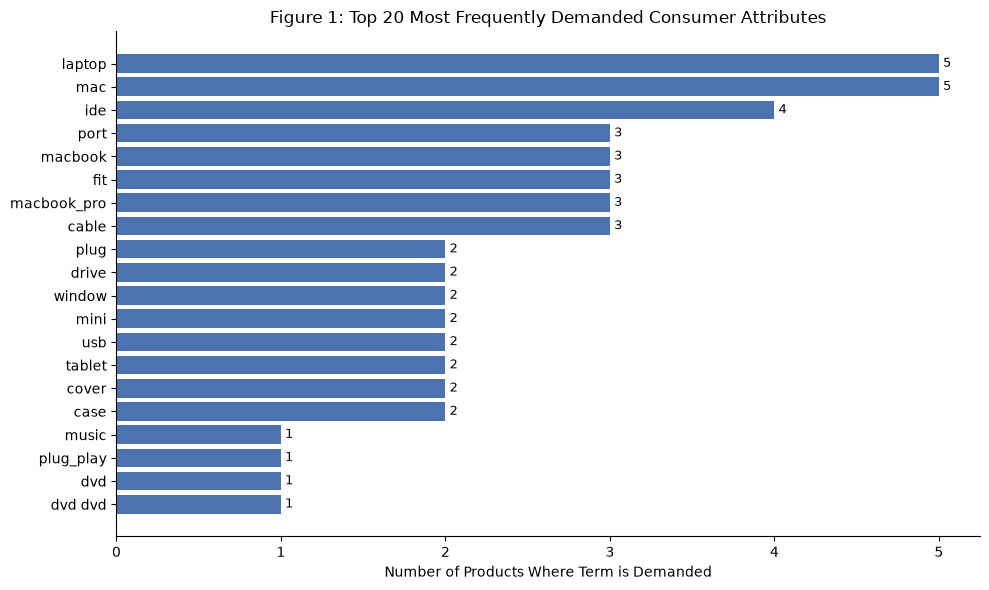

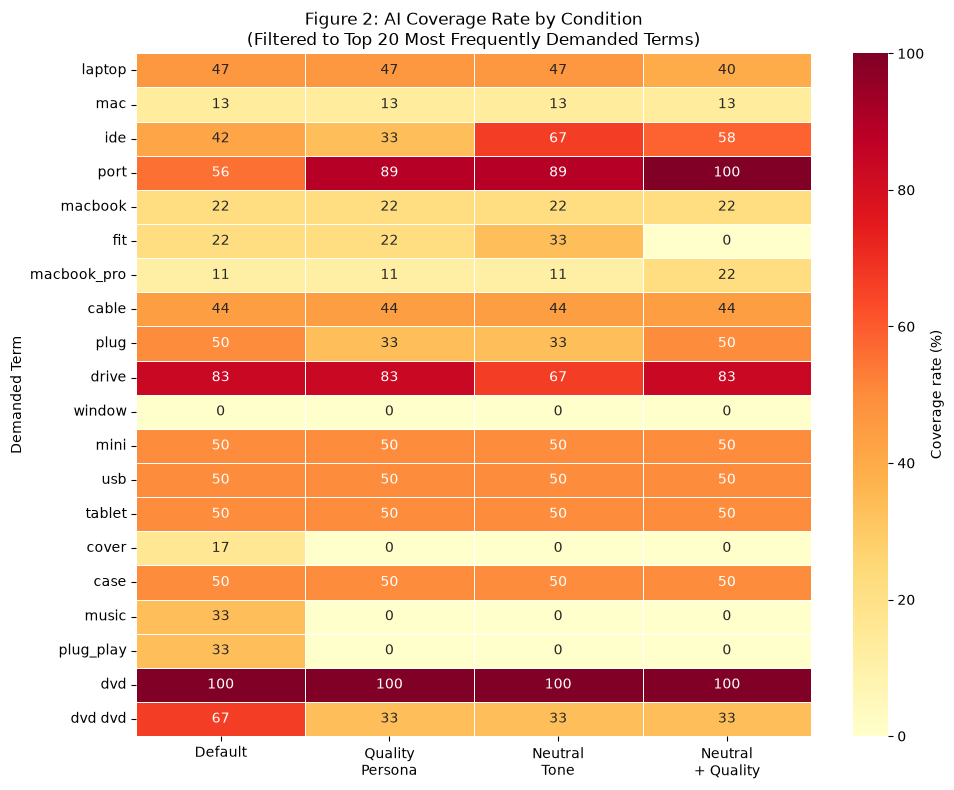

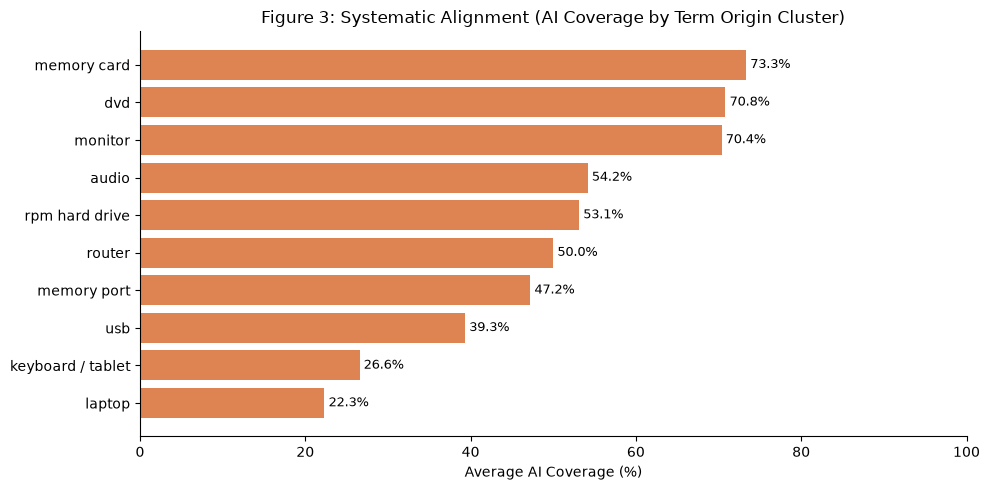

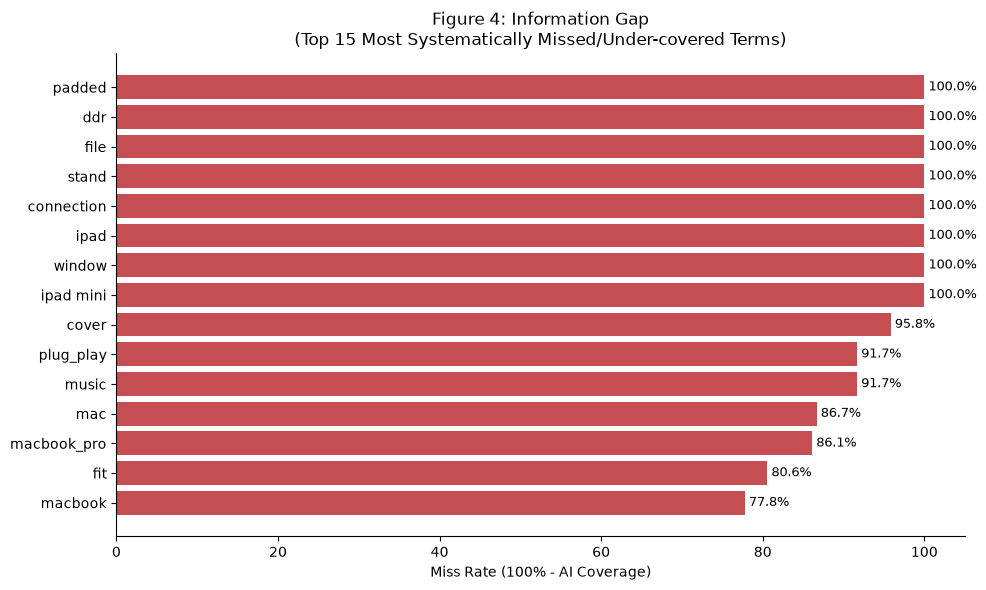


Skipping Figure 5: No over-coverage detected in the dataset.


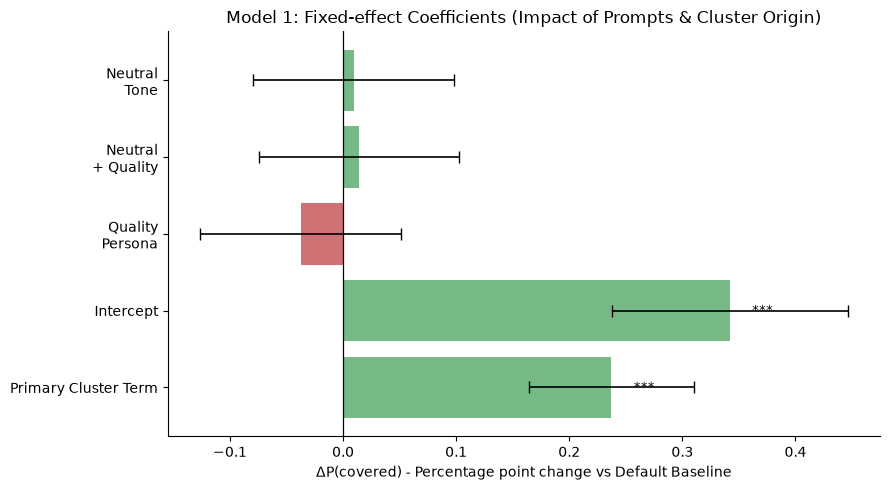

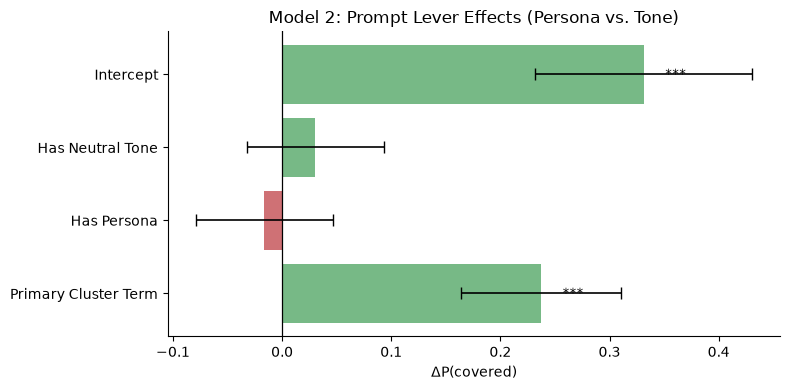

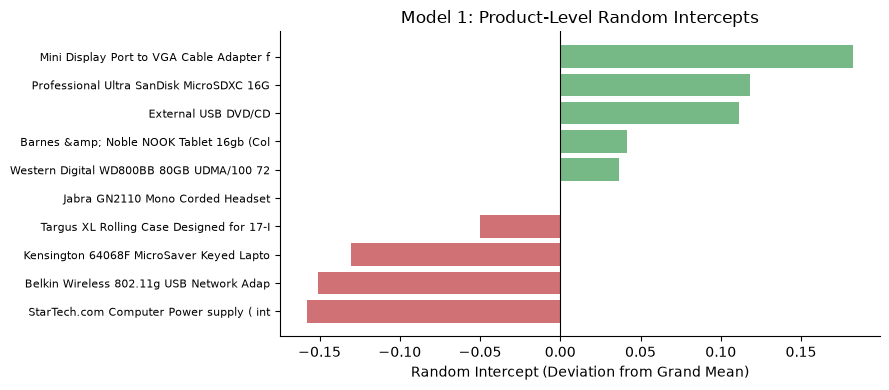

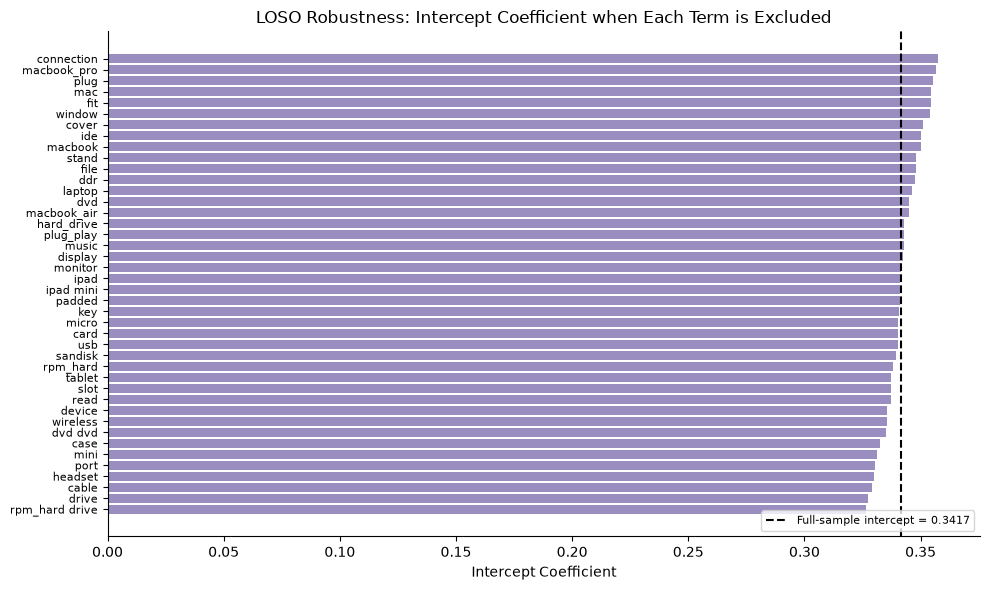


All updated figures saved/rendered.


In [ ]:
# visualizations
import matplotlib.patches as mpatches
import seaborn as sns
import textwrap

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {
    "demand": "#4C72B0",
    "ai": "#DD8452",
    "human": "#55A868",
    "over": "#8172B2",
    "under": "#C44E52",
    "pos": "#55A868",
    "neg": "#C44E52",
    "neutral": "#8172B2",
}
COND_LABELS = {
    "default": "Default",
    "quality_persona": "Quality\nPersona",
    "neutral_tone": "Neutral\nTone",
    "neutral_tone_quality_persona": "Neutral\n+ Quality",
    "human": "Human",
}
# fig 1 most frequently demanded terms
# Calculate how many products demand each term
term_freq = {}
for asin, terms in product_demanded_subtopics.items():
    for t in terms:
        term_freq[t] = term_freq.get(t, 0) + 1
freq_df = pd.Series(term_freq).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([textwrap.fill(t, 15) for t in freq_df.index], freq_df.values, color=COLORS["demand"])
ax.bar_label(bars, padding=3, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Number of Products Where Term is Demanded")
ax.set_title("Figure 1: Top 20 Most Frequently Demanded Consumer Attributes")
plt.tight_layout()
#plt.savefig("fig1_top_demanded_terms.png", dpi=150)
plt.show()

# fig 2 coverage heatmap
fig, ax = plt.subplots(figsize=(10, 8))
plot_matrix = condition_term_cov.loc[freq_df.index] * 100
present_conds = [c for c in COND_LABELS if c in plot_matrix.columns]
plot_matrix = plot_matrix[present_conds]

sns.heatmap(
    plot_matrix,
    annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    xticklabels=[COND_LABELS[c] for c in present_conds],
    ax=ax, cbar_kws={"label": "Coverage rate (%)"},
    vmin=0, vmax=100,
)
ax.set_title("Figure 2: AI Coverage Rate by Condition\n(Filtered to Top 20 Most Frequently Demanded Terms)")
ax.set_xlabel("")
ax.set_ylabel("Demanded Term")
plt.tight_layout()
#plt.savefig("fig2_term_coverage_heatmap.png", dpi=150)
plt.show()

# fig 3 coverage by cluster
cluster_cov = gap_df.groupby("term_cluster")["ai_coverage"].mean().sort_values() * 100
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([textwrap.fill(c, 20) for c in cluster_cov.index], cluster_cov.values, color=COLORS["ai"])
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel("Average AI Coverage (%)")
ax.set_title("Figure 3: Systematic Alignment (AI Coverage by Term Origin Cluster)")
plt.tight_layout()
#plt.savefig("fig3_systematic_misalignment_cluster.png", dpi=150)
plt.show()

# fig 4 information gap
worst_gaps = gap_df.head(15)
miss_vals = worst_gaps["miss_rate"].values * 100
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([textwrap.fill(t, 15) for t in worst_gaps.index], miss_vals, color=COLORS["under"])
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Miss Rate (100% - AI Coverage)")
ax.set_title("Figure 4: Information Gap\n(Top 15 Most Systematically Missed/Under-covered Terms)")
plt.tight_layout()
#plt.savefig("fig4_information_gap_misses.png", dpi=150)
plt.show()

# fig 5 over-coverage
if not overcov_df.empty:
    over_counts = overcov_df.groupby("term")["asin"].count().sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh([textwrap.fill(t, 15) for t in over_counts.index], over_counts.values, color=COLORS["over"])
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Frequency Included (When Demand = 0)")
    ax.set_title("Figure 5: AI Over-coverage / Unprompted Detail\n(Attributes provided despite no consumer demand)")
    plt.tight_layout()
    #plt.savefig("fig5_overcoverage.png", dpi=150)
    plt.show()
else:
    print("\nSkipping Figure 5: No over-coverage detected in the dataset.")

# help for plotting models
def clean_label(k):
    if "condition" in k:
        raw = k.split("[T.")[-1].rstrip("]")
        return COND_LABELS.get(raw, raw)
    if k == "is_primary_cluster":
        return "Primary Cluster Term"
    return k.replace("_", " ").title()

# fig a model 1 coefficients
fig, ax = plt.subplots(figsize=(9, 5))
_keep = [k for k in c1.index if k not in ("Group Var")]
_plot = c1.loc[_keep].copy()
labels_plot = [clean_label(k) for k in _plot.index]
vals = _plot["coef"].values
lo = _plot["CI_2.5"].values
hi = _plot["CI_97.5"].values
pvals = _plot["p"].values
colors_m1 = [COLORS["neg"] if v < 0 else COLORS["pos"] for v in vals]
y = np.arange(len(vals))
ax.barh(y, vals, xerr=[vals - lo, hi - vals], capsize=4, color=colors_m1, alpha=0.80, error_kw={"elinewidth": 1.2})
ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(y)
ax.set_yticklabels(labels_plot)
ax.set_xlabel("ΔP(covered) - Percentage point change vs Default Baseline")
ax.set_title("Model 1: Fixed-effect Coefficients (Impact of Prompts & Cluster Origin)")
ax.invert_yaxis()
for i, (v, p) in enumerate(zip(vals, pvals)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    if sig:
        ax.text(v + (0.02 if v >= 0 else -0.02), i, sig, va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
#plt.savefig("figA_model1_coef.png", dpi=150)
plt.show()

# fig b model 2 coefficients
fig, ax = plt.subplots(figsize=(8, 4))
_keep2 = [k for k in c2.index if k not in ("Group Var")]
_plot2 = c2.loc[_keep2].copy()
labels2 = [clean_label(k) for k in _plot2.index]
vals2 = _plot2["coef"].values
lo2 = _plot2["CI_2.5"].values
hi2= _plot2["CI_97.5"].values
pvals2= _plot2["p"].values
colors_m2 = [COLORS["neg"] if v < 0 else COLORS["pos"] for v in vals2]
y2 = np.arange(len(vals2))
ax.barh(y2, vals2, xerr=[vals2 - lo2, hi2 - vals2], capsize=4, color=colors_m2, alpha=0.80, error_kw={"elinewidth": 1.2})
ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(y2)
ax.set_yticklabels(labels2)
ax.set_xlabel("ΔP(covered)")
ax.set_title("Model 2: Prompt Lever Effects (Persona vs. Tone)")
ax.invert_yaxis()
for i, (v, p) in enumerate(zip(vals2, pvals2)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    if sig:
        ax.text(v + (0.02 if v >= 0 else -0.02), i, sig, va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
#plt.savefig("figB_model2_levers.png", dpi=150)
plt.show()

# fig c random intercepts
if re_df is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    re_sorted = re_df.sort_values("intercept")
    colors_re = [COLORS["pos"] if v >= 0 else COLORS["neg"] for v in re_sorted["intercept"]]
    ax.barh(range(len(re_sorted)), re_sorted["intercept"], color=colors_re, alpha=0.80)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(range(len(re_sorted)))
    ax.set_yticklabels([textwrap.fill(t, 40) for t in re_sorted["title"]], fontsize=8)
    ax.set_xlabel("Random Intercept (Deviation from Grand Mean)")
    ax.set_title("Model 1: Product-Level Random Intercepts")
    plt.tight_layout()
    #plt.savefig("figC_random_intercepts.png", dpi=150)
    plt.show()

#fig d loso robustness
fig, ax = plt.subplots(figsize=(10, 6))
loso_plot   = loso_df.sort_values("b_intercept")
b_full_plot = c1.loc["Intercept", "coef"] if "Intercept" in c1.index else 0
colors_loso = [COLORS["neg"] if abs(v - b_full_plot) > 0.05 else COLORS["neutral"] for v in loso_plot["b_intercept"]]
ax.barh(range(len(loso_plot)), loso_plot["b_intercept"], color=colors_loso, alpha=0.80)
ax.axvline(b_full_plot, color="black", linewidth=1.5, linestyle="--", label=f"Full-sample intercept = {b_full_plot:.4f}")
ax.axvline(0, color="gray", linewidth=0.6)
ax.set_yticks(range(len(loso_plot)))
ax.set_yticklabels(loso_plot.index, fontsize=8)
ax.set_xlabel("Intercept Coefficient")
ax.set_title("LOSO Robustness: Intercept Coefficient when Each Term is Excluded")
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
#plt.savefig("figD_loso_robustness.png", dpi=150)
plt.show()

print("\nAll updated figures saved/rendered.")